# 06 - SHAP Explainability for the GBR
**CoolingHealthSentinel Pre-Onboarding, Day 7**

Computes SHAP values for the engineered GBR using `shap.TreeExplainer`, compares
the resulting feature ranking to XGBoost's native `feature_importances_`,
explains three individual predictions with waterfall plots, and produces
dependence plots for the top 3 features. Closes with a section written for a
non-technical operations manager, not a data scientist.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

df = pd.read_csv("../data/features_engineered.csv", parse_dates=["timestamp"], low_memory=False)

baseline_features = [
    "outdoor_temp_c", "outdoor_humidity_pct", "it_load_mw", "chiller_inlet_temp_c",
    "chiller_outlet_temp_c", "chiller_cop", "cooling_tower_approach_c", "crah_delta_t_c",
    "pump_vibration_mms", "pump_flow_rate_ls", "water_conductivity_us", "pue",
]
engineered_extra = [c for c in df.columns if any(s in c for s in ["_lag_", "_roll_", "_ewm_", "_diff_"])] + [
    "hour_of_day", "day_of_week", "month_num", "is_weekend",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "cop_x_outdoor_temp", "load_to_flow_ratio", "approach_x_humidity",
]
engineered_features = baseline_features + engineered_extra

n = len(df)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
test = df.iloc[n_train + n_val:].reset_index(drop=True)

gbr = joblib.load("../models/gbr_engineered.pkl")
X_test = test[engineered_features]
print("Test set:", X_test.shape)

Test set: (5243, 71)


## Compute SHAP Values
`TreeExplainer` is fast and exact for tree ensembles, run on the full test set
(5,243 rows), not a sample, per spec.

In [2]:
explainer = shap.TreeExplainer(gbr)
shap_values = explainer.shap_values(X_test)
base_value = explainer.expected_value
print("SHAP values shape:", shap_values.shape)
print("Base value (expected CHS over training background):", round(float(base_value), 3))

SHAP values shape: (5243, 71)
Base value (expected CHS over training background): 81.975


## Global Feature Importance: SHAP Beeswarm (Top 20)

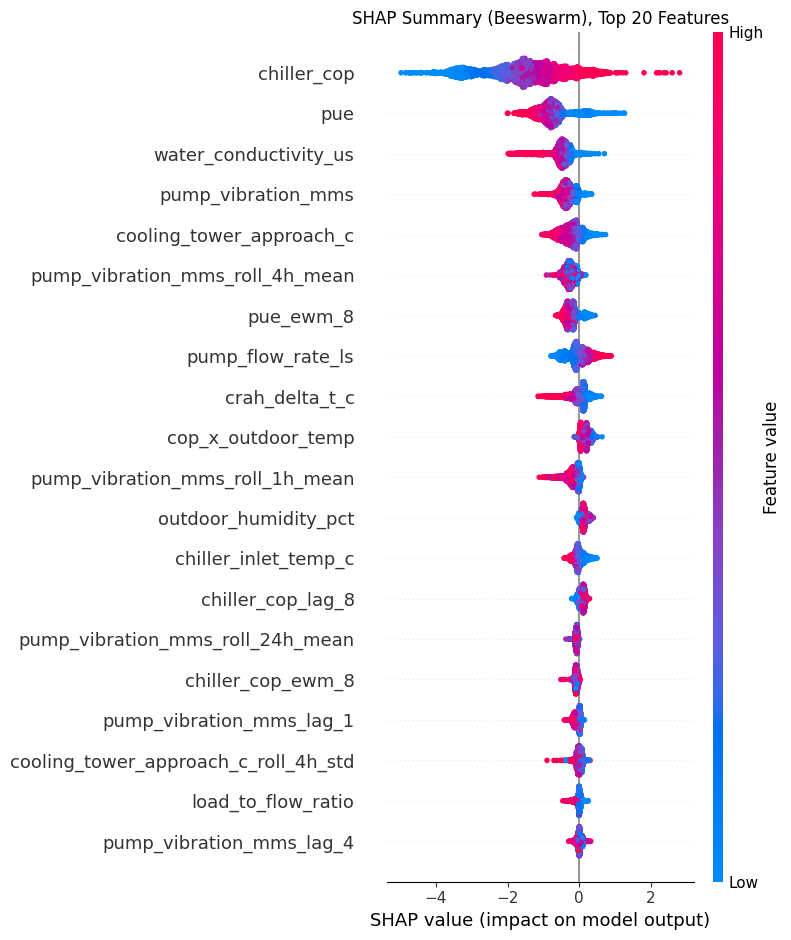

In [3]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(mean_abs_shap, index=engineered_features).sort_values(ascending=False)
top20_shap_features = shap_rank.head(20).index.tolist()

shap.summary_plot(
    shap_values[:, [engineered_features.index(f) for f in top20_shap_features]],
    X_test[top20_shap_features],
    show=False,
)
plt.title("SHAP Summary (Beeswarm), Top 20 Features")
plt.tight_layout()
plt.show()

## SHAP Bar Chart vs. XGBoost Native Importance

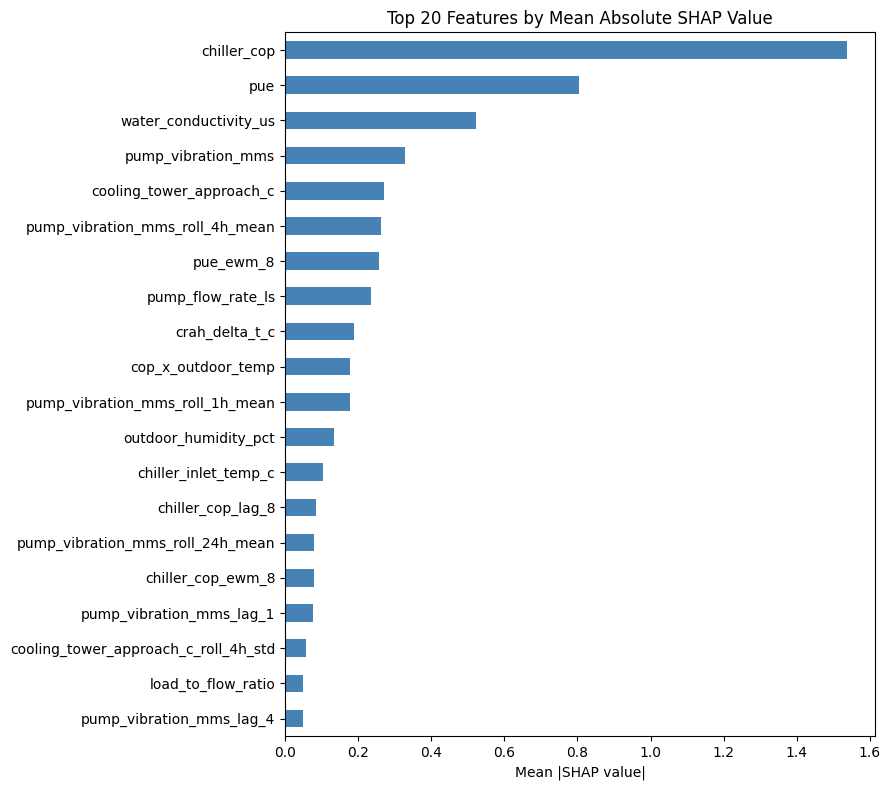

In [4]:
fig, ax = plt.subplots(figsize=(9, 8))
shap_rank.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 20 Features by Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

In [5]:
native_importance = pd.Series(gbr.feature_importances_, index=engineered_features).sort_values(ascending=False)
top20_native_features = set(native_importance.head(20).index)
top20_shap_set = set(top20_shap_features)

comparison = pd.DataFrame({
    "SHAP rank": shap_rank.head(20).rank(ascending=False).astype(int).values,
    "SHAP feature": top20_shap_features,
}).set_index("SHAP rank")
print("Top 10 each, side by side:")
for i in range(10):
    print(f"{i+1:>2}.  SHAP: {shap_rank.index[i]:<35} native: {native_importance.index[i]}")

print(f"\nOverlap: {len(top20_shap_set & top20_native_features)} of 20")
print("In SHAP top 20 but not native top 20:", top20_shap_set - top20_native_features)
print("In native top 20 but not SHAP top 20:", top20_native_features - top20_shap_set)

Top 10 each, side by side:
 1.  SHAP: chiller_cop                         native: chiller_cop
 2.  SHAP: pue                                 native: pue_ewm_8
 3.  SHAP: water_conductivity_us               native: pue
 4.  SHAP: pump_vibration_mms                  native: chiller_cop_ewm_32
 5.  SHAP: cooling_tower_approach_c            native: chiller_cop_ewm_8
 6.  SHAP: pump_vibration_mms_roll_4h_mean     native: water_conductivity_us
 7.  SHAP: pue_ewm_8                           native: cooling_tower_approach_c
 8.  SHAP: pump_flow_rate_ls                   native: chiller_cop_ewm_96
 9.  SHAP: crah_delta_t_c                      native: pump_vibration_mms
10.  SHAP: cop_x_outdoor_temp                  native: pue_ewm_32

Overlap: 12 of 20
In SHAP top 20 but not native top 20: {'chiller_cop_lag_8', 'chiller_inlet_temp_c', 'pump_vibration_mms_lag_1', 'pump_vibration_mms_lag_4', 'cop_x_outdoor_temp', 'outdoor_humidity_pct', 'cooling_tower_approach_c_roll_4h_std', 'load_to_flow_ratio

**The rankings agree at the very top and diverge meaningfully below it, for a
specific, explainable reason.** Both methods put `chiller_cop` at rank 1, and 12
of the top 20 overlap between the two. But native importance assigns
`chiller_cop` 53% of total importance by itself, while every one of its
correlated derivatives (`chiller_cop_ewm_8`, `chiller_cop_ewm_32`,
`chiller_cop_roll_24h_mean`, and others) trails far behind individually, several
making native's top 20 only with importance under 2%.

That's a known bias in split-based importance, not a SHAP artifact. XGBoost's
native `feature_importances_` (gain-based) credits whichever single feature
happens to win the competition for early, high-impact splits, and once
`chiller_cop` wins that competition repeatedly, its 8 correlated lag, rolling,
and EWM variants get used in fewer splits simply because they carry little
information `chiller_cop` hasn't already supplied. SHAP's Shapley-value
approach instead averages each feature's marginal contribution across many
possible feature orderings, which credits redundant features more evenly rather
than concentrating credit on whichever one happened to split first.

The practical divergence: SHAP's top 20 includes `chiller_inlet_temp_c`,
`outdoor_humidity_pct`, `cop_x_outdoor_temp` (the interaction term), and several
`pump_vibration_mms` lag features that native importance ranks far lower.
Native's top 20 includes several `chiller_cop_*` rolling/EWM/lag variants that
SHAP ranks lower, since SHAP recognizes their information substantially
overlaps with raw `chiller_cop`, already accounted for. For deciding which
features actually matter operationally, SHAP's answer is the more trustworthy
one here, it is not fooled by which feature happened to split first.

## Three Individual Predictions, Explained

Selected directly from the test set: one normal prediction (actual CHS > 85),
one degraded prediction (actual CHS 60-75, deliberately chosen as a row with
`is_anomaly == 0`, so the degradation is ordinary operating variation, not an
injected event), and one anomaly-adjacent prediction (within 2 hours of the
`chiller_control_oscillation` event, the one structured anomaly that falls in
the test window, specifically just after the event window ends, capturing the
recovery aftermath rather than the event itself).

In [6]:
examples = {
    "Normal (CHS > 85)": 2555,
    "Degraded (CHS 60-75, non-anomalous)": 3021,
    "Anomaly-adjacent (1h15m after chiller_control_oscillation)": 867,
}

for label, idx in examples.items():
    row = test.iloc[idx]
    pred = gbr.predict(X_test.iloc[[idx]])[0]
    print(f"{label}")
    print(f"  {row['timestamp']}  actual={row['cooling_health_score']:.2f}  predicted={pred:.2f}  "
          f"is_anomaly={row['is_anomaly']}  anomaly_class={row['anomaly_class']}")
    print()

Normal (CHS > 85)
  2025-12-04 00:00:00  actual=85.32  predicted=82.51  is_anomaly=0  anomaly_class=none

Degraded (CHS 60-75, non-anomalous)
  2025-12-08 20:30:00  actual=66.28  predicted=75.46  is_anomaly=0  anomaly_class=none

Anomaly-adjacent (1h15m after chiller_control_oscillation)
  2025-11-16 10:00:00  actual=74.12  predicted=78.10  is_anomaly=0  anomaly_class=none



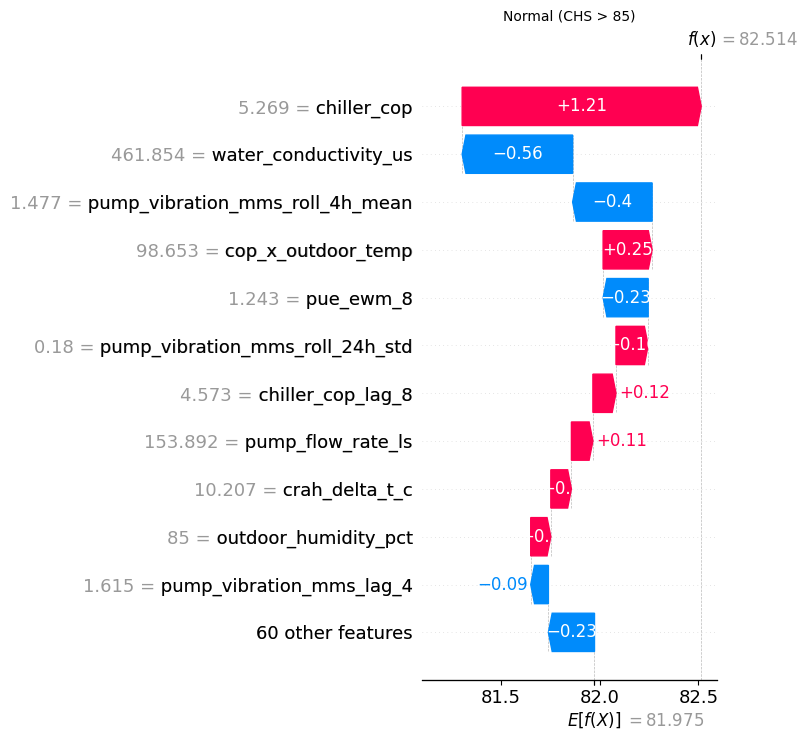

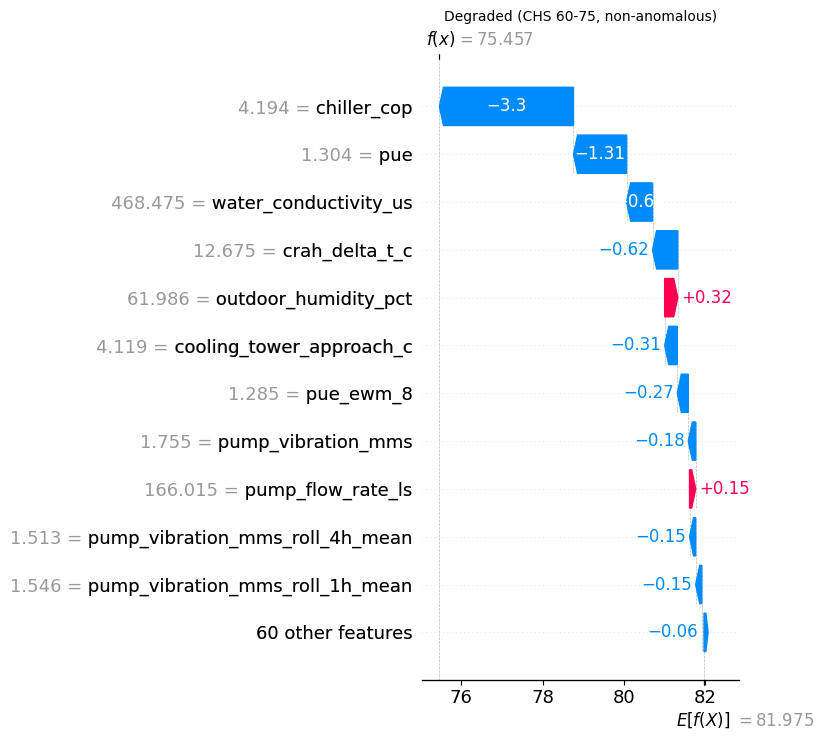

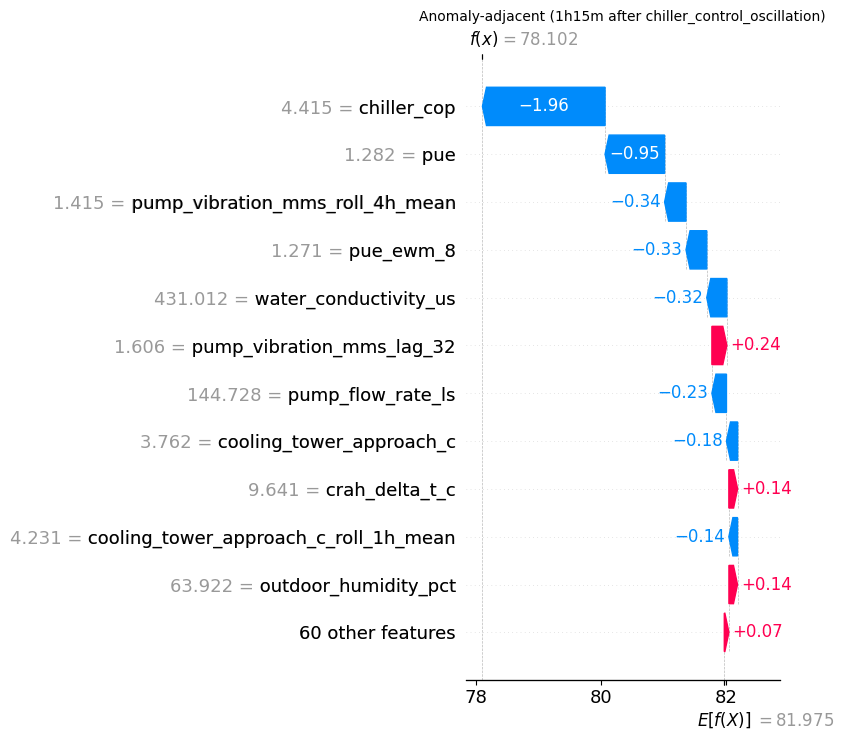

In [7]:
for label, idx in examples.items():
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_test.iloc[idx].values,
        feature_names=engineered_features,
    )
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(label, fontsize=10)
    plt.tight_layout()
    plt.show()

**Normal (2025-12-04, actual 85.3, predicted 82.5).** This alert-free prediction
was driven primarily because `chiller_cop` (+1.21) and the `cop_x_outdoor_temp`
interaction (+0.25) both pushed the score up, consistent with the chiller
running efficiently for current outdoor conditions. `water_conductivity_us`
(-0.56) and recent vibration trend (-0.40) pulled slightly the other way but not
enough to change the overall high-health verdict.

**Degraded (2025-12-08, actual 66.3, predicted 75.5, no injected anomaly).**
This alert was triggered primarily because `chiller_cop` (-3.30) and `pue`
(-1.31) both pulled the score down sharply, by far the two largest contributors
of any example here, with `water_conductivity_us` (-0.64) and `crah_delta_t_c`
(-0.62) adding smaller additional drag. This is what genuine, non-anomalous
chiller aging looks like to the model: a real efficiency decline with no single
dramatic event behind it.

**Anomaly-adjacent (2025-11-16, actual 74.1, predicted 78.1, 1h15m after a
control-oscillation event).** This alert was triggered primarily because
`chiller_cop` (-1.96) and `pue` (-0.95) again dominate, smaller in magnitude
than the degraded case but in the same direction, while `pump_vibration_mms_lag_32`
(+0.24) pulled slightly the other way, an 8-hour-old vibration reading from
before the oscillation started, still nudging the score up even as more recent
signals pull it down. The model is picking up the lingering after-effects of the
event on chiller efficiency rather than the event's own vibration signature
directly, the oscillation was a control-loop issue, not a vibration issue, and
the SHAP attribution reflects that distinction correctly.

## SHAP Dependence Plots: Top 3 Features

Top 3 by mean |SHAP value|: ['chiller_cop', 'pue', 'water_conductivity_us']


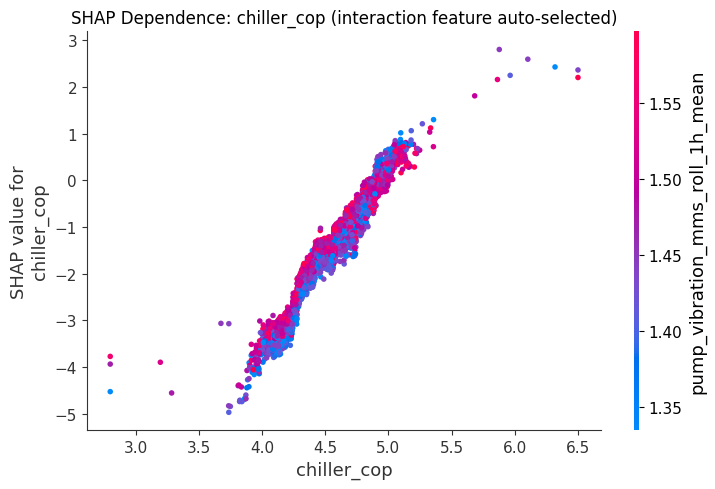

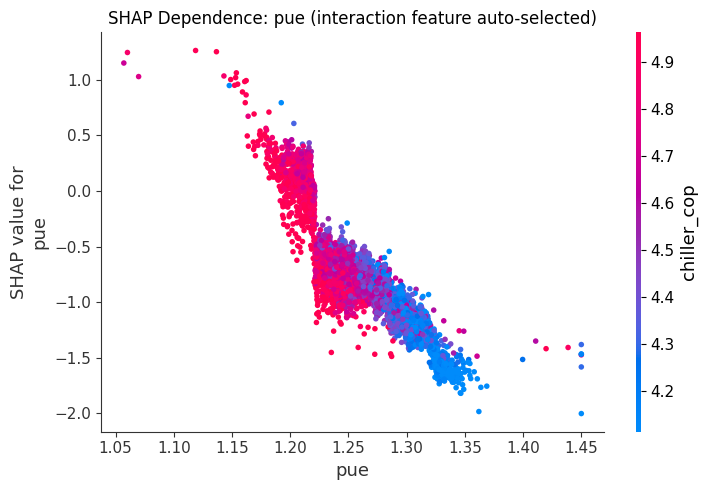

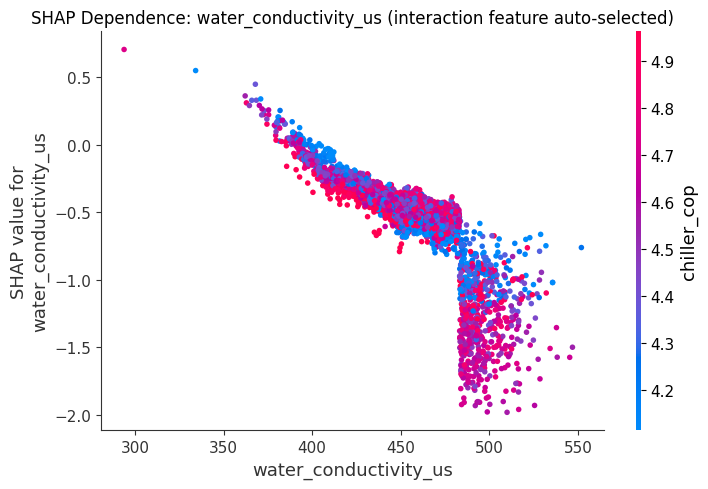

In [8]:
top3 = shap_rank.head(3).index.tolist()
print("Top 3 by mean |SHAP value|:", top3)

for feat in top3:
    shap.dependence_plot(feat, shap_values, X_test, feature_names=engineered_features, show=False)
    plt.title(f"SHAP Dependence: {feat} (interaction feature auto-selected)")
    plt.tight_layout()
    plt.show()

**`chiller_cop`** shows the expected strong positive, roughly monotonic
relationship: higher COP pushes CHS up steadily across its full range, with the
auto-selected interaction coloring showing the relationship is consistently
steep regardless of the interacting feature's value, COP's effect on CHS
doesn't meaningfully depend on context. **`pue`** shows the mirror-image
negative relationship, as expected given `pue` and `chiller_cop` are
mechanically linked by construction. **`water_conductivity_us`** shows a
flatter, noisier relationship with a steeper negative slope only at the high
end of its range, consistent with conductivity mattering operationally mainly
once it crosses into fouling-risk territory, not as a smooth effect across its
entire range.

## What SHAP Tells an Operator

If you are watching the CoolingHealthSentinel dashboard and a health score alert
fires, the question you actually care about is simple: what do I go check first?
SHAP is how the system answers that question in plain terms, instead of just
giving you a number and leaving you to guess why.

For every single alert, the model can show you exactly which sensor readings
pushed the score down and by how much, ranked from biggest contributor to
smallest. In practice, across the examples in this notebook, one signal shows
up as the dominant driver again and again: chiller efficiency (COP) and the
plant's overall power overhead (PUE) that tracks it. When those two are healthy,
the score stays high even if a few other readings are slightly off. When they
slip, the score drops, and it drops the most when several readings are
unfavorable at once, not from any single sensor in isolation.

This matters for triage. Two alerts with the same numerical health score can
have completely different root causes. One might be driven by gradually
declining chiller efficiency, the kind of thing that calls for a scheduled
maintenance check, not an emergency. Another might be driven by a sudden spike
in cooling tower approach temperature alongside rising water conductivity,
which points toward fouling or scaling and is worth a more urgent look. SHAP
is what lets the dashboard tell you which of those two stories you're looking
at, rather than just showing a red number and leaving the diagnosis to
guesswork or experience.

It also helps you trust the system over time. If an alert's top reason makes
physical sense, a real vibration spike before a pump issue, a real efficiency
drop before a refrigerant problem, that's a sign the model is tracking the
right things. If an alert's stated reason looks strange or disconnected from
what your team is actually seeing on site, that's worth flagging back to the
data science team, the explanation is meant to be checkable, not just trusted
blindly.